In [1]:
using Random
using Printf
using Statistics
using Plots


In [2]:
function tsplib_euc_2d(p::NTuple{2,Float64}, q::NTuple{2,Float64})
    dx = p[1] - q[1]
    dy = p[2] - q[2]
    return round(Int, sqrt(dx*dx + dy*dy))
end

function distance_matrix(coords::Vector{NTuple{2,Float64}}; metric=:tsplib)
    n = length(coords)
    D = zeros(Float64, n, n)
    @inbounds for i in 1:n
        for j in i+1:n
            d = metric === :tsplib ? tsplib_euc_2d(coords[i], coords[j]) : hypot(coords[i][1]-coords[j][1], coords[i][2]-coords[j][2])
            D[i,j] = d
            D[j,i] = d
        end
    end
    return D
end

coords_berlin52 = [
    (565.0, 575.0), (25.0, 185.0), (345.0, 750.0), (945.0, 685.0), (845.0, 655.0),
    (880.0, 660.0), (25.0, 230.0), (525.0, 1000.0), (580.0, 1175.0), (650.0, 1130.0),
    (1605.0, 620.0), (1220.0, 580.0), (1465.0, 200.0), (1530.0, 5.0), (845.0, 680.0),
    (725.0, 370.0), (145.0, 665.0), (415.0, 635.0), (510.0, 875.0), (560.0, 365.0),
    (300.0, 465.0), (520.0, 585.0), (480.0, 415.0), (835.0, 625.0), (975.0, 580.0),
    (1215.0, 245.0), (1320.0, 315.0), (1250.0, 400.0), (660.0, 180.0), (410.0, 250.0),
    (420.0, 555.0), (575.0, 665.0), (1150.0, 1160.0), (700.0, 580.0), (685.0, 595.0),
    (685.0, 610.0), (770.0, 610.0), (795.0, 645.0), (720.0, 635.0), (760.0, 650.0),
    (475.0, 960.0), (95.0, 260.0), (875.0, 920.0), (700.0, 500.0), (555.0, 815.0),
    (830.0, 485.0), (1170.0, 65.0), (830.0, 610.0), (605.0, 625.0), (595.0, 360.0),
    (1340.0, 725.0), (1740.0, 245.0)
]

D_berlin = distance_matrix(coords_berlin52; metric=:tsplib)
N = length(coords_berlin52)


52

In [3]:
function tour_length(tour::AbstractVector{<:Integer}, D::AbstractMatrix{<:Real})
    n = length(tour)
    s = 0.0
    @inbounds for k in 1:(n-1)
        s += D[tour[k], tour[k+1]]
    end
    s += D[tour[n], tour[1]]
    return s
end

function plot_tour(coords::Vector{NTuple{2,Float64}}, tour::AbstractVector{<:Integer}; ttl::AbstractString="Тур")
    xs = [coords[i][1] for i in tour]
    ys = [coords[i][2] for i in tour]
    xs = vcat(xs, xs[1])
    ys = vcat(ys, ys[1])
    p = plot(xs, ys; lw=2, color=:black, legend=false, title=ttl, xlabel="x", ylabel="y")
    scatter!(p, [c[1] for c in coords], [c[2] for c in coords]; ms=3, color=:blue)
    return p
end


plot_tour (generic function with 1 method)

In [4]:
abstract type CoolingSchedule end

struct GeometricCooling <: CoolingSchedule
    T0::Float64
    alpha::Float64
end

struct LogarithmicCooling <: CoolingSchedule
    T0::Float64
end

struct SuperFastCooling <: CoolingSchedule
    T0::Float64
    beta::Float64
    d::Int
end

temperature(s::GeometricCooling, t::Int) = s.T0 * (s.alpha^(t - 1))
temperature(s::LogarithmicCooling, t::Int) = s.T0 / log(t + 1)
temperature(s::SuperFastCooling, t::Int) = s.T0 * exp(-s.beta * (t^(1.0 / s.d)))

metropolis_accept(Δ::Float64, T::Float64, rng::AbstractRNG) = (Δ <= 0) || (rand(rng) < exp(-Δ / T))


function delta_2opt(tour::Vector{Int}, i::Int, k::Int, D)
    n = length(tour)
    a = tour[mod1(i-1, n)]
    b = tour[i]
    c = tour[k]
    d = tour[mod1(k+1, n)]
    
    return (D[a,c] + D[b,d]) - (D[a,b] + D[c,d])
end

function apply_2opt!(tour::Vector{Int}, i::Int, k::Int)
    reverse!(tour, i, k)
    return tour
end

function simulated_annealing_tsp_2opt(D::AbstractMatrix{<:Real}, tour0::Vector{Int};
    schedule::CoolingSchedule,
    max_iter::Int=200_000,
    T_min::Float64=1e-8,
    stall_iters::Int=30_000,
    save_frames::Bool=false,
    frame_stride::Int=2000,
    rng::AbstractRNG=Random.default_rng()
)
    n = length(tour0)
    tour = copy(tour0)
    cur_len = tour_length(tour, D)

    best_tour = copy(tour)
    best_len = cur_len
    best_hist = Float64[]
    push!(best_hist, best_len)

    saved_tours = Vector{Vector{Int}}()
    saved_lens  = Float64[]
    saved_iters = Int[]
    if save_frames
        push!(saved_tours, copy(best_tour))
        push!(saved_lens, best_len)
        push!(saved_iters, 0)
    end

    last_improve = 0
    t_start = time_ns()

    for t in 1:max_iter
        T = temperature(schedule, t)
        if !(isfinite(T)) || T <= T_min
            break
        end

        
        i = rand(rng, 1:n-1)
        k = rand(rng, i+1:n)
        if k == i || k == i+1 || (i == 1 && k == n)
            push!(best_hist, best_len)
            continue
        end

        Δ = delta_2opt(tour, i, k, D)
        if metropolis_accept(Δ, T, rng)
            apply_2opt!(tour, i, k)
            cur_len += Δ
        end

        if cur_len < best_len - 1e-9
            best_len = cur_len
            best_tour = copy(tour)
            last_improve = t
        end

        push!(best_hist, best_len)

        if save_frames && (t == 1 || t == max_iter || (t % frame_stride == 0))
            push!(saved_tours, copy(best_tour))
            push!(saved_lens, best_len)
            push!(saved_iters, t)
        end

        if (t - last_improve) >= stall_iters
            break
        end
    end

    elapsed_s = (time_ns() - t_start) / 1e9
    return (best_tour=best_tour, best_len=best_len, best_history=best_hist, saved_iters=saved_iters, saved_tours=saved_tours, saved_lens=saved_lens, elapsed_s=elapsed_s)
end


simulated_annealing_tsp_2opt (generic function with 1 method)

In [5]:
function roulette_index(weights::AbstractVector{<:Real}, rng::AbstractRNG=Random.default_rng())
    total = 0.0
    @inbounds for w in weights
        total += w
    end
    if !(total > 0)
        return rand(rng, 1:length(weights))
    end
    r = rand(rng) * total
    acc = 0.0
    @inbounds for i in eachindex(weights)
        acc += weights[i]
        if acc >= r
            return i
        end
    end
    return lastindex(weights)
end

function ant_system_tsp_best_trace(
    D::AbstractMatrix{<:Real};
    iters::Int=200,
    N::Int=size(D,1),
    α::Float64=1.0,
    β::Float64=5.0,
    ρ::Float64=0.9,
    Q::Float64=20.0,
    τ0::Float64=1e-6,
    elitist::Int=2,
    directed_pheromone::Bool=false,
    seed::Int=32,
    save_frames::Bool=false,
    frame_stride::Int=5,
    stall_iters::Int=typemax(Int)
)
    rng = MersenneTwister(seed)
    n = size(D, 1)

    τ = fill(τ0, n, n)
    η = zeros(Float64, n, n)
    @inbounds for i in 1:n
        for j in 1:n
            if i != j
                dij = float(D[i,j])
                η[i,j] = dij > 0 ? 1.0 / dij : 0.0
            end
        end
    end

    best_tour = collect(1:n)
    best_len = Inf
    best_history = Vector{Float64}(undef, iters)

    saved_tours = Vector{Vector{Int}}()
    saved_lens  = Float64[]
    saved_iters = Int[]
    saved_tau   = Vector{Matrix{Float64}}()

    allowed = Vector{Int}(undef, n-1)
    weights = Vector{Float64}(undef, n-1)

    last_improve = 0

    for t in 1:iters
        prev_best = best_len
        tours = Vector{Vector{Int}}(undef, N)
        lens  = Vector{Float64}(undef, N)

        @inbounds for k in 1:N
            start = rand(rng, 1:n)
            tour = Vector{Int}(undef, n)
            tour[1] = start

            visited = falses(n)
            visited[start] = true
            cur = start

            for step in 2:n
                m = 0
                for j in 1:n
                    if !visited[j]
                        m += 1
                        allowed[m] = j
                    end
                end
                for idx in 1:m
                    j = allowed[idx]
                    weights[idx] = (τ[cur, j]^α) * (η[cur, j]^β)
                end
                chosen_idx = roulette_index(view(weights, 1:m), rng)
                next_city = allowed[chosen_idx]

                tour[step] = next_city
                visited[next_city] = true
                cur = next_city
            end

            L = tour_length(tour, D)
            tours[k] = tour
            lens[k] = L

            if L < best_len
                best_len = L
                best_tour = copy(tour)
            end
        end

        best_history[t] = best_len
        if best_len < prev_best - 1e-9
            last_improve = t
        end
        if (t - last_improve) >= stall_iters
            
            for tt in (t+1):iters
                best_history[tt] = best_len
            end
            break
        end

        if save_frames && (t == 1 || t == iters || (t % frame_stride == 0))
            push!(saved_tours, copy(best_tour))
            push!(saved_lens, best_len)
            push!(saved_iters, t)
            push!(saved_tau, Matrix{Float64}(τ))
        end

        τ .*= (1.0 - ρ)

        @inbounds for k in 1:N
            Δ = Q / lens[k]
            tour = tours[k]
            for s in 1:(n-1)
                i = tour[s]
                j = tour[s+1]
                τ[i,j] += Δ
                if !directed_pheromone
                    τ[j,i] += Δ
                end
            end
            i = tour[end]
            j = tour[1]
            τ[i,j] += Δ
            if !directed_pheromone
                τ[j,i] += Δ
            end
        end

        if elitist > 0
            kbest = argmin(lens)
            tour = tours[kbest]
            Δe = elitist * (Q / lens[kbest])
            @inbounds for s in 1:(n-1)
                i = tour[s]
                j = tour[s+1]
                τ[i,j] += Δe
                if !directed_pheromone
                    τ[j,i] += Δe
                end
            end
            i = tour[end]
            j = tour[1]
            τ[i,j] += Δe
            if !directed_pheromone
                τ[j,i] += Δe
            end
        end
    end

    return (
        best_tour=best_tour,
        best_len=best_len,
        best_history=best_history,
        saved_iters=saved_iters,
        saved_tours=saved_tours,
        saved_lens=saved_lens,
        saved_tau=saved_tau
    )
end


ant_system_tsp_best_trace (generic function with 1 method)

In [6]:
using Base64

GIF_DIR = "gifs"
mkpath(GIF_DIR)
CACHE_DIR = "gifs_cache"
mkpath(CACHE_DIR)

safe_filename(s::AbstractString) = replace(lowercase(s), r"[^a-z0-9]+" => "_")

function show_gif_inline(path::AbstractString)
    data = base64encode(read(path))
    html = "<img src=\"data:image/gif;base64,$data\" />"
    
    try
        display("text/html", html)
    catch
        println("GIF сохранён: ", path)
    end
    return nothing
end

function plot_tour_with_pheromone(
    coords::Vector{NTuple{2,Float64}},
    tour::AbstractVector{<:Integer},
    τ::AbstractMatrix{<:Real};
    ttl::AbstractString="",
    fade_scale::Float64=1.0,
    gamma::Float64=0.30
)
    n = length(coords)
    τmax = maximum(τ)
    τmax = τmax > 0 ? τmax : 1.0

    plt = plot(legend=false, xlabel="x", ylabel="y", title=ttl)
    @inbounds for i in 1:(n-1)
        xi, yi = coords[i]
        for j in (i+1):n
            v = float(τ[i,j])
            a = clamp(v / τmax, 0.0, 1.0) ^ gamma
            αedge = clamp((0.06 + 0.94*a) * fade_scale, 0.0, 1.0)
            lw = 0.25 + 2.4*a
            xj, yj = coords[j]
            plot!(plt, [xi, xj], [yi, yj], color=RGBA(0.05, 0.18, 0.95, αedge), lw=lw, label="")
        end
    end

    xs = [coords[i][1] for i in tour]
    ys = [coords[i][2] for i in tour]
    push!(xs, coords[tour[1]][1])
    push!(ys, coords[tour[1]][2])
    plot!(plt, xs, ys, seriestype=:path, color=:red, lw=3, label="")
    scatter!(plt, [c[1] for c in coords], [c[2] for c in coords], ms=3.0, color=:orange, markerstrokewidth=0.4, label="")
    return plt
end

function make_aco_tour_gif(name::AbstractString, coords, D; iters=200, N=size(D,1), α=1.0, β=5.0, ρ=0.9, Q=20.0, τ0=1e-6, elitist=2, directed_pheromone=false, seed=32, frame_stride=5, fps=8)
    res = ant_system_tsp_best_trace(D; iters, N, α, β, ρ, Q, τ0, elitist, directed_pheromone, seed, save_frames=true, frame_stride)

    mean0 = mean(res.saved_tau[1])
    mean0 = mean0 > 0 ? mean0 : 1.0

    cache = mkpath(joinpath(CACHE_DIR, safe_filename(name) * "_aco"))
    anim = Animation(cache)

    for idx in eachindex(res.saved_tours)
        t = res.saved_iters[idx]
        L = res.saved_lens[idx]
        τsnap = res.saved_tau[idx]
        fade = clamp((mean(τsnap) / mean0) ^ 0.85, 0.12, 1.0)
        p = plot_tour_with_pheromone(coords, res.saved_tours[idx], τsnap; ttl="$(name): t=$(t), L=$(round(L, digits=2))", fade_scale=fade, gamma=0.30)
        frame(anim, p)
    end

    out = joinpath(GIF_DIR, safe_filename(name) * "_aco.gif")
    gif(anim, out, fps=fps)
    rm(cache; recursive=true, force=true)
    println("GIF сохранён: ", out)
    show_gif_inline(out)
    return out
end

function make_sa_tour_gif(name::AbstractString, coords, D, tour0; schedule, max_iter=250_000, T_min=0.0, stall_iters=typemax(Int), seed=32, frame_stride=2000, fps=10)
    res = simulated_annealing_tsp_2opt(D, tour0; schedule=schedule, max_iter=max_iter, T_min=T_min, stall_iters=stall_iters, save_frames=true, frame_stride=frame_stride, rng=MersenneTwister(seed))
    cache = mkpath(joinpath(CACHE_DIR, safe_filename(name) * "_sa"))
    anim = Animation(cache)
    for idx in eachindex(res.saved_tours)
        t = res.saved_iters[idx]
        L = res.saved_lens[idx]
        p = plot_tour(coords, res.saved_tours[idx]; ttl="$(name): t=$(t), L=$(round(L, digits=1))")
        frame(anim, p)
    end
    out = joinpath(GIF_DIR, safe_filename(name) * "_sa.gif")
    gif(anim, out, fps=fps)
    rm(cache; recursive=true, force=true)
    println("GIF сохранён: ", out)
    show_gif_inline(out)
    return out
end


make_sa_tour_gif (generic function with 1 method)

GIF сохранён: gifs\berlin52_aco.gif


[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\let8\gifs\berlin52_aco.gif



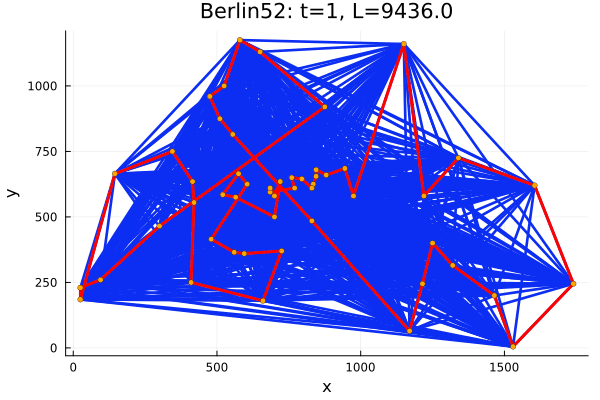

GIF сохранён: gifs\berlin52_sa_geom_sa.gif


[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\let8\gifs\berlin52_sa_geom_sa.gif



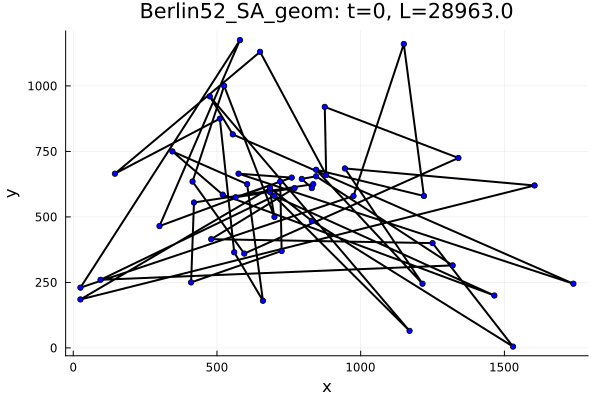

[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\let8\gifs\berlin52_sa_log_sa.gif


GIF сохранён: gifs\berlin52_sa_log_sa.gif



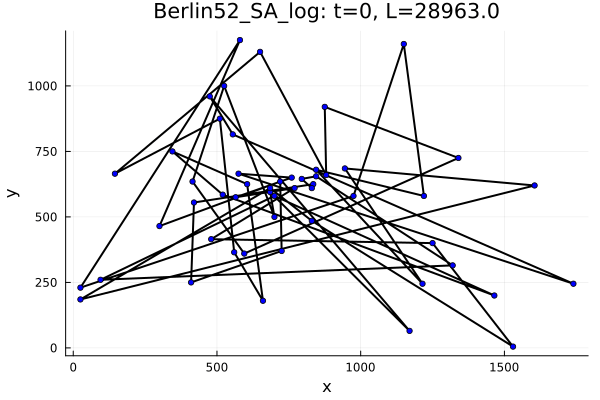

GIF сохранён: gifs\berlin52_sa_super_sa.gif


[ Info: Saved animation to D:\Programming\Projects\8 Semestr\Optimization\let8\gifs\berlin52_sa_super_sa.gif



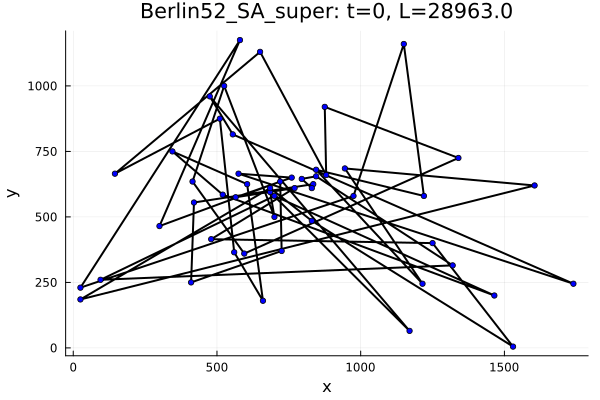

"gifs\\berlin52_sa_super_sa.gif"

In [7]:
seed_gif = isdefined(Main, :seed) ? seed : 32
tour0_gif = isdefined(Main, :tour0) ? tour0 : (let r=MersenneTwister(seed_gif); t=collect(1:N); shuffle!(r,t); t; end)
sa_geom_gif  = isdefined(Main, :sa_geom)  ? sa_geom  : GeometricCooling(50.0, 0.99995)
sa_log_gif   = isdefined(Main, :sa_log)   ? sa_log   : LogarithmicCooling(50.0)
sa_super_gif = isdefined(Main, :sa_super) ? sa_super : SuperFastCooling(50.0, 0.02, N)

make_aco_tour_gif("Berlin52", coords_berlin52, D_berlin; iters=200, N=N, seed=seed_gif, frame_stride=5, fps=8)

make_sa_tour_gif("Berlin52_SA_geom",  coords_berlin52, D_berlin, tour0_gif; schedule=sa_geom_gif,  max_iter=250_000, seed=seed_gif, frame_stride=5000, fps=10)
make_sa_tour_gif("Berlin52_SA_log",   coords_berlin52, D_berlin, tour0_gif; schedule=sa_log_gif,   max_iter=250_000, seed=seed_gif, frame_stride=5000, fps=10)
make_sa_tour_gif("Berlin52_SA_super", coords_berlin52, D_berlin, tour0_gif; schedule=sa_super_gif, max_iter=250_000, seed=seed_gif, frame_stride=5000, fps=10)

In [9]:
OPT_BERLIN52 = 7542.0
gap(len) = (len - OPT_BERLIN52) / OPT_BERLIN52 * 100

seed = 32
rng = MersenneTwister(seed)


tour0 = collect(1:N)
shuffle!(rng, tour0)


sa_geom  = GeometricCooling(50.0, 0.99995)
sa_log   = LogarithmicCooling(50.0)
sa_super = SuperFastCooling(50.0, 0.02, N)


stall_common = 40_000
sa_kwargs = (max_iter=250_000, T_min=1e-8, stall_iters=stall_common)


simulated_annealing_tsp_2opt(D_berlin, tour0; schedule=sa_geom, max_iter=2000, stall_iters=500)
ant_system_tsp_best_trace(D_berlin; iters=5, N=N, seed=seed, stall_iters=stall_common)

res_sa_geom  = simulated_annealing_tsp_2opt(D_berlin, tour0; schedule=sa_geom,  sa_kwargs..., rng=MersenneTwister(seed))
res_sa_log   = simulated_annealing_tsp_2opt(D_berlin, tour0; schedule=sa_log,   sa_kwargs..., rng=MersenneTwister(seed))
res_sa_super = simulated_annealing_tsp_2opt(D_berlin, tour0; schedule=sa_super, sa_kwargs..., rng=MersenneTwister(seed))

t0 = time_ns()
res_aco = ant_system_tsp_best_trace(D_berlin; iters=200, N=N, α=1.0, β=5.0, ρ=0.9, Q=20.0, τ0=1e-6, elitist=2, seed=seed, stall_iters=stall_common)
aco_elapsed_s = (time_ns() - t0) / 1e9

@printf("=== SA vs ACO (Berlin52) ===\n")
@printf("SA Геометрическое (синий):   %.4f сек, L=%.1f, gap=%.2f%%\n", res_sa_geom.elapsed_s,  res_sa_geom.best_len,  gap(res_sa_geom.best_len))
@printf("SA Логарифмическое (красный): %.4f сек, L=%.1f, gap=%.2f%%\n", res_sa_log.elapsed_s,   res_sa_log.best_len,   gap(res_sa_log.best_len))
@printf("SA Сверхбыстрое (жёлтый):     %.4f сек, L=%.1f, gap=%.2f%%\n", res_sa_super.elapsed_s, res_sa_super.best_len, gap(res_sa_super.best_len))
@printf("ACO (серый):                 %.4f сек, L=%.1f, gap=%.2f%%\n", aco_elapsed_s, res_aco.best_len, gap(res_aco.best_len))
nothing


=== SA vs ACO (Berlin52) ===
SA Геометрическое (синий):   0.0057 сек, L=8204.0, gap=8.78%
SA Логарифмическое (красный): 0.0028 сек, L=8090.0, gap=7.27%
SA Сверхбыстрое (жёлтый):     0.0105 сек, L=7927.0, gap=5.10%
ACO (серый):                 0.2572 сек, L=7679.0, gap=1.82%


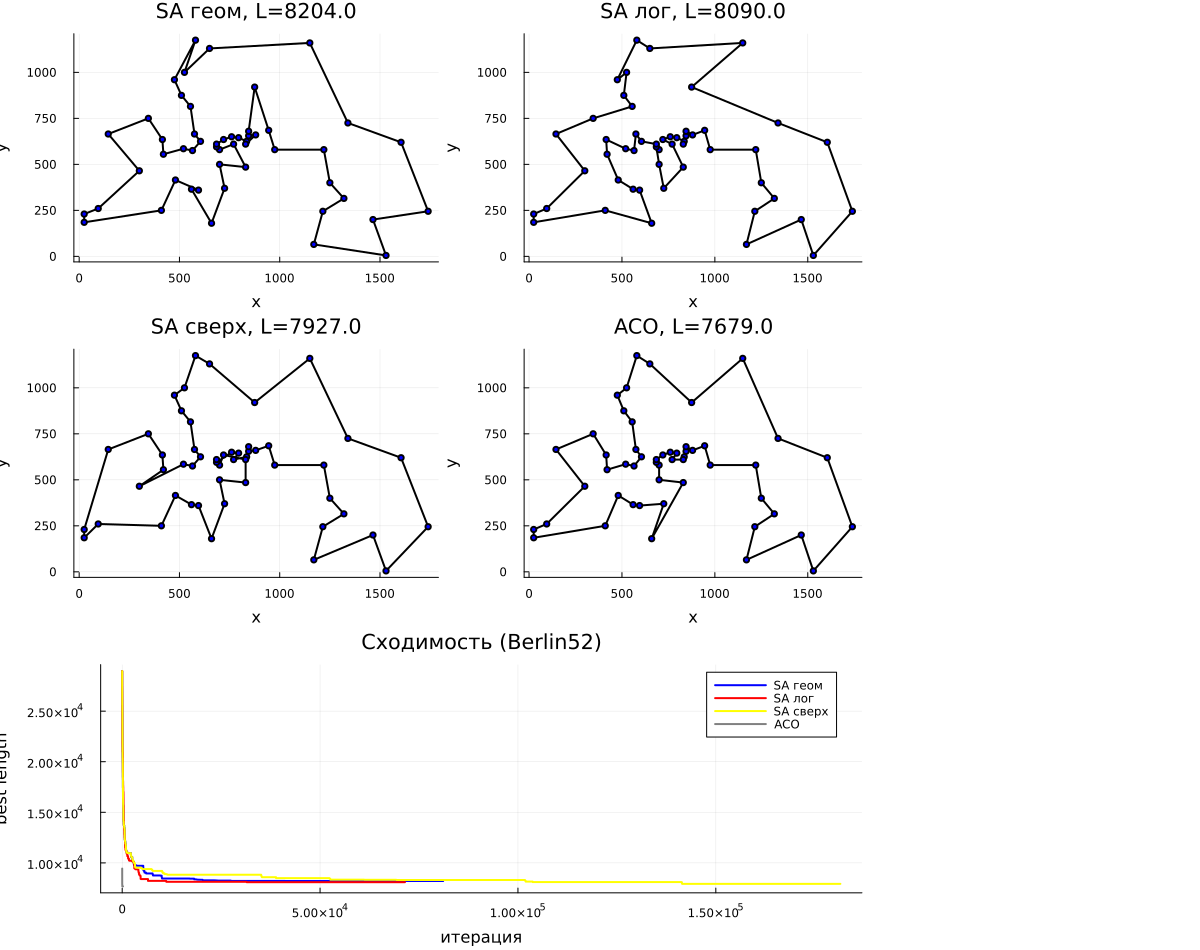

In [10]:
p_sa_g = plot_tour(coords_berlin52, res_sa_geom.best_tour;  ttl="SA геом, L=$(round(res_sa_geom.best_len, digits=1))")
p_sa_l = plot_tour(coords_berlin52, res_sa_log.best_tour;   ttl="SA лог, L=$(round(res_sa_log.best_len, digits=1))")
p_sa_s = plot_tour(coords_berlin52, res_sa_super.best_tour; ttl="SA сверх, L=$(round(res_sa_super.best_len, digits=1))")
p_aco  = plot_tour(coords_berlin52, res_aco.best_tour;      ttl="ACO, L=$(round(res_aco.best_len, digits=1))")

p_conv = plot(res_sa_geom.best_history; color=:blue, lw=2, label="SA геом")
plot!(p_conv, res_sa_log.best_history;  color=:red, lw=2, label="SA лог")
plot!(p_conv, res_sa_super.best_history; color=:yellow, lw=2, label="SA сверх")
plot!(p_conv, res_aco.best_history;     color=:gray, lw=2, label="ACO")
plot!(p_conv; xlabel="итерация", ylabel="best length", title="Сходимость (Berlin52)")

plot(p_sa_g, p_sa_l, p_sa_s, p_aco, p_conv; layout=@layout([a b; c d; e{0.7w}]), size=(1200, 950))
